<a href="https://colab.research.google.com/github/vidyashiremath/machinelearning/blob/main/assignment(ipl).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

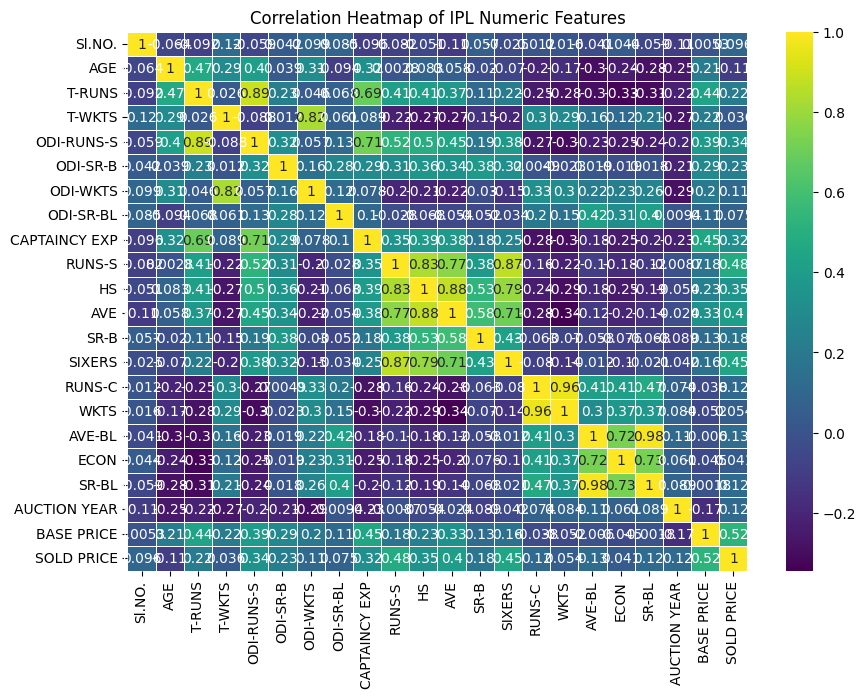

Training RMSE : 239910.34
Testing RMSE  : 309833.49

Regression Coefficients
       Attributes        Weights
8   CAPTAINCY EXP  182340.139882
19   AUCTION YEAR   58325.659783
11            AVE    6421.715954
16         AVE-BL    3438.490591
0          Sl.NO.     876.109348
6        ODI-WKTS     642.785207
9          RUNS-S     353.892628
14         RUNS-C     274.149514
13         SIXERS     154.987899
4      ODI-RUNS-S      67.363018
20     BASE PRICE       1.258700
3          T-WKTS     -33.418864
2          T-RUNS     -76.746667
12           SR-B    -464.796508
5        ODI-SR-B    -673.222726
7       ODI-SR-BL   -1366.713897
15           WKTS   -3808.838100
18          SR-BL   -4385.241495
10             HS   -4735.763489
17           ECON   -6276.074933
1             AGE -199884.612840


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Read dataset
ipl = pd.read_csv("IPL IMB381IPL2013.csv")

# Select only numerical columns
data = ipl.select_dtypes(include=np.number)

# Correlation matrix
corr = data.corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr, cmap="viridis", annot=True, linewidths=0.5)
plt.title("Correlation Heatmap of IPL Numeric Features")
plt.show()

# Independent and dependent variables
features = data.drop(columns=["SOLD PRICE"])
target = data["SOLD PRICE"]

# Split dataset
x_train, x_test, y_train, y_test = train_test_split(
    features,
        target,
            test_size=0.25,
                random_state=7
                )

                # Train model
lr = LinearRegression()
lr.fit(x_train, y_train)

                # Prediction
train_output = lr.predict(x_train)
test_output = lr.predict(x_test)

                # RMSE
train_error = np.sqrt(mean_squared_error(y_train, train_output))
test_error = np.sqrt(mean_squared_error(y_test, test_output))

print("Training RMSE :", round(train_error,2))
print("Testing RMSE  :", round(test_error,2))

                # Feature importance
result = pd.DataFrame({
                    "Attributes": features.columns,
                        "Weights": lr.coef_
                        })

print("\nRegression Coefficients")
print(result.sort_values(by="Weights", ascending=False))